# Preamble

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import hedgehogs as hdg

## Figure configuration

In [2]:
figure_size = hdg.figsize()
palette = hdg.get_palette()
hdg.set_style()
figure_root = Path.cwd() / "output" / "figures"
figure_root.mkdir(parents=True, exist_ok=True)

## Data

In [3]:
x = np.linspace(0, 10, 200)
response = np.sin(x)
sample_x = np.linspace(0, 10, 15)
sample_response = np.sin(sample_x)
coordinates = np.linspace(0, 1, 80)
X, Y = np.meshgrid(coordinates, coordinates)
field = np.exp(-((X - 0.4)**2 + (Y - 0.6)**2) / 0.025)

## Line plot

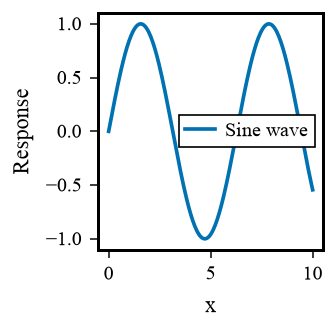

In [4]:
fig, ax = plt.subplots(figsize=figure_size)
ax.plot(x, response, label="Sine wave")
ax.legend(loc="best")
ax.set(xlabel="x", ylabel="Response")
hdg.plots.save(figure_root / "line_plot.pdf", dpi=600)
hdg.plots.show()

## Scatter plot

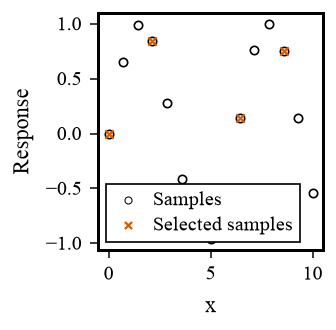

In [5]:
fig, ax = plt.subplots(figsize=figure_size)
ax.scatter(sample_x, sample_response, facecolors="white", edgecolors="black", label="Samples")
ax.scatter(sample_x[::3], sample_response[::3], marker="x", color=palette["red"], label="Selected samples")
ax.legend(loc="best")
ax.set(xlabel="x", ylabel="Response")
hdg.plots.save(figure_root / "scatter_plot.pdf", dpi=600)
hdg.plots.show()

## Rectangular figure

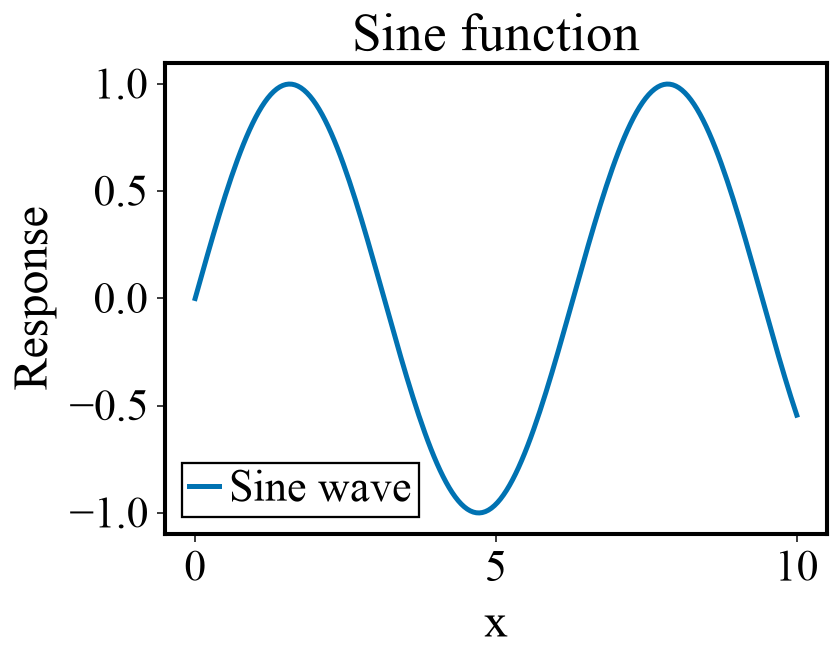

In [6]:
fig, ax = plt.subplots(figsize=(figure_size[0] * 2.5, figure_size[1] * 2))
ax.plot(x, response, label="Sine wave")
ax.set(title="Sine function", xlabel="x", ylabel="Response")
ax.legend(loc="best")
hdg.plots.save(figure_root / "line_plot.pdf", dpi=600)
hdg.plots.show()

## Contour plot

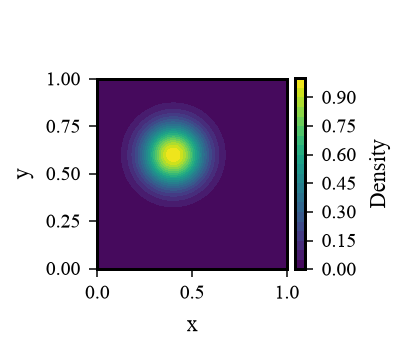

In [7]:
fig, ax = plt.subplots(figsize=(figure_size[0] * 1.2, figure_size[1] * 1.1))
image = ax.contourf(X, Y, field, levels=20, cmap="viridis")
ax.set(xlabel="x", ylabel="y")
ax.set_box_aspect(1)
colourbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colourbar.set_label("Density")
hdg.plots.save(figure_root / "contour_plot.pdf", dpi=600)
hdg.plots.show()

## Image plot

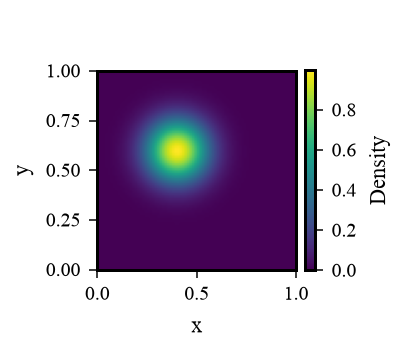

In [8]:
fig, ax = plt.subplots(figsize=(figure_size[0] * 1.2, figure_size[1] * 1.1))
image = ax.imshow(field, origin="lower", extent=(0, 1, 0, 1), cmap="viridis", aspect="auto")
ax.set(xlabel="x", ylabel="y")
ax.set_box_aspect(1)
colourbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colourbar.set_label("Density")
hdg.plots.save(figure_root / "image_plot.pdf", dpi=600)
hdg.plots.show()

## Probability field

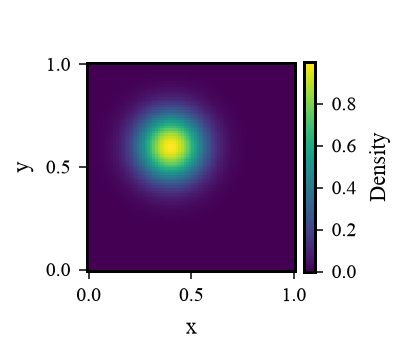

In [9]:
fig, ax = plt.subplots(figsize=(figure_size[0] * 1.2, figure_size[1] * 1.1))
image = ax.pcolormesh(
    X, Y, field, shading="auto", cmap="viridis",
    edgecolors="none", linewidth=0, antialiased=False, rasterized=True,
)
ax.set(xlabel="x", ylabel="y")
ax.set_box_aspect(1)
colourbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
colourbar.set_label("Density")
hdg.plots.save(figure_root / "probability_field.pdf", dpi=600)
hdg.plots.show()

## Bar plot

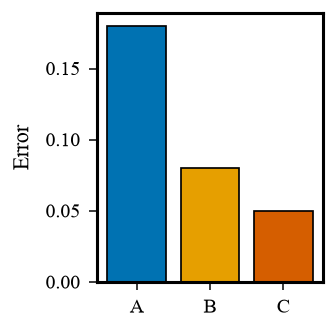

In [10]:
fig, ax = plt.subplots(figsize=figure_size)
ax.bar(["A", "B", "C"], [0.18, 0.08, 0.05], color=palette[:3])
ax.set(ylabel="Error")
hdg.plots.save(figure_root / "bar.pdf")
hdg.plots.show()

## Subplots

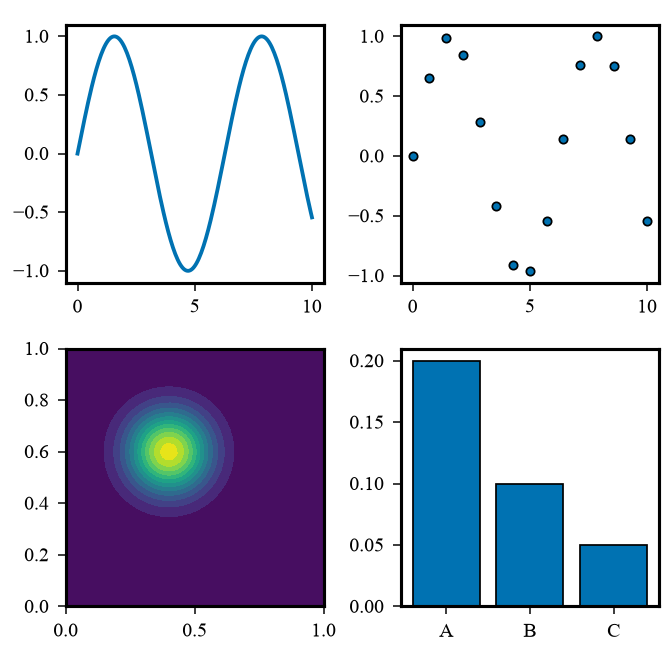

In [11]:
fig, axes = plt.subplots(
    2, 2, figsize=(figure_size[0] * 2, figure_size[1] * 2),
)
axes[0, 0].plot(x, response)
axes[0, 1].scatter(sample_x, sample_response)
axes[1, 0].contourf(X, Y, field, levels=15)
axes[1, 1].bar(["A", "B", "C"], [0.2, 0.1, 0.05])
for ax in axes.flat:
    ax.set_box_aspect(1)
hdg.plots.save(figure_root / "subplots.pdf")
hdg.plots.show()

## Unequal panels

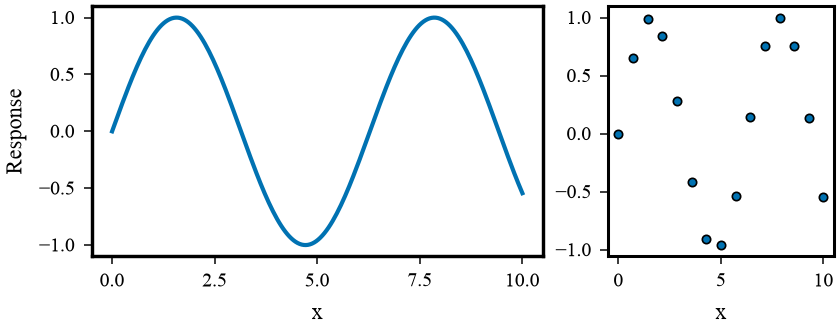

In [12]:
fig, axes = plt.subplots(
    1, 2, figsize=(figure_size[0] * 2.5, figure_size[1]),
    gridspec_kw={"width_ratios": [2, 1]}, layout="constrained",
)
axes[0].plot(x, response)
axes[0].set(xlabel="x", ylabel="Response")
axes[1].scatter(sample_x, sample_response)
axes[1].set_xlabel("x")
hdg.plots.show()

## Transparent export

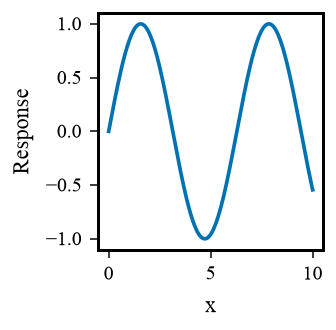

In [13]:
fig, ax = plt.subplots(figsize=figure_size)
ax.plot(x, response)
ax.set(xlabel="x", ylabel="Response")
hdg.plots.save(figure_root / "transparent.png", transparent=True)
hdg.plots.show()